# Heston Calibration Assessment

This notebook provides analysis and visualizations for the Master's dissertation.

**Prerequisites:**
1. Run `data_collection.ipynb` to fetch market data
2. Run `python main.py --tickers QQQ SPY TSLA` to calibrate models

**Contents:**
1. Load Results
2. Performance Comparison
3. Parameter Analysis
4. Pricing Accuracy
5. Volatility Surface Visualization
6. Export Tables for Dissertation

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import json

# Add project root
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston_model import HestonModel

# Plotting settings for publication
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

# Directories
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = DATA_DIR / 'models'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

---

## 1. Load Results

In [2]:
# Load master results
master_file = MODELS_DIR / 'master_results.json'

if not master_file.exists():
    print(f" Results not found: {master_file}")
    print("\nPlease run the calibration first:")
    print("    python main.py --tickers QQQ SPY TSLA")
else:
    with open(master_file) as f:
        master_results = json.load(f)
    
    tickers = master_results['tickers']
    results = master_results['results']
    
    print(f"Loaded results for: {tickers}")
    print(f"Timestamp: {master_results['timestamp']}")

Loaded results for: ['QQQ', 'SPY', 'TSLA']
Timestamp: 2025-11-28T19:29:55.191364


In [3]:
# Load individual results and calibration data
calibration_data = {}

for ticker in tickers:
    # Load calibration data
    calib_file = DATA_DIR / 'processed' / 'calibration' / f'{ticker}_calibration.csv'
    if calib_file.exists():
        calibration_data[ticker] = pd.read_csv(calib_file)
        print(f"Loaded {len(calibration_data[ticker])} options for {ticker}")

Loaded 107 options for QQQ
Loaded 134 options for SPY
Loaded 47 options for TSLA


---

## 2. Performance Comparison

### 2.1 Summary Table

In [4]:
# Create comparison DataFrame
comparison_data = []

for ticker in tickers:
    r = results[ticker]
    comparison_data.append({
        'Ticker': ticker,
        'Spot ($)': r['spot'],
        'N Options': r['n_options'],
        'Trad RMSE ($)': r['traditional']['rmse'],
        'NN RMSE ($)': r['nn_surrogate']['rmse'],
        'Trad MAE ($)': r['traditional']['mae'],
        'NN MAE ($)': r['nn_surrogate']['mae'],
        'Trad Time (s)': r['traditional']['time'],
        'NN Time (s)': r['nn_surrogate']['time'],
        'Speedup': r['speedup']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("CALIBRATION PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))


CALIBRATION PERFORMANCE COMPARISON
Ticker   Spot ($)  N Options  Trad RMSE ($)  NN RMSE ($)  Trad MAE ($)  NN MAE ($)  Trad Time (s)  NN Time (s)  Speedup
   QQQ 619.250000        107       0.492300     0.526355      0.375631    0.422285       6.006934     1.672622 3.591328
   SPY 683.469971        134       0.552452     0.928245      0.433466    0.750834       5.335488     2.223524 2.399564
  TSLA 430.170013         47       0.737593     1.919167      0.536094    1.288267       2.490578     3.064031 0.812844


In [5]:
# Save table for dissertation
comparison_df.to_csv(TABLES_DIR / 'performance_comparison.csv', index=False)
comparison_df.to_latex(TABLES_DIR / 'performance_comparison.tex', index=False, 
                       float_format='%.4f', caption='Calibration Performance Comparison',
                       label='tab:performance')
print(f"Saved to: {TABLES_DIR / 'performance_comparison.csv'}")

Saved to: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/results/tables/performance_comparison.csv


### 2.2 Visual Comparisons

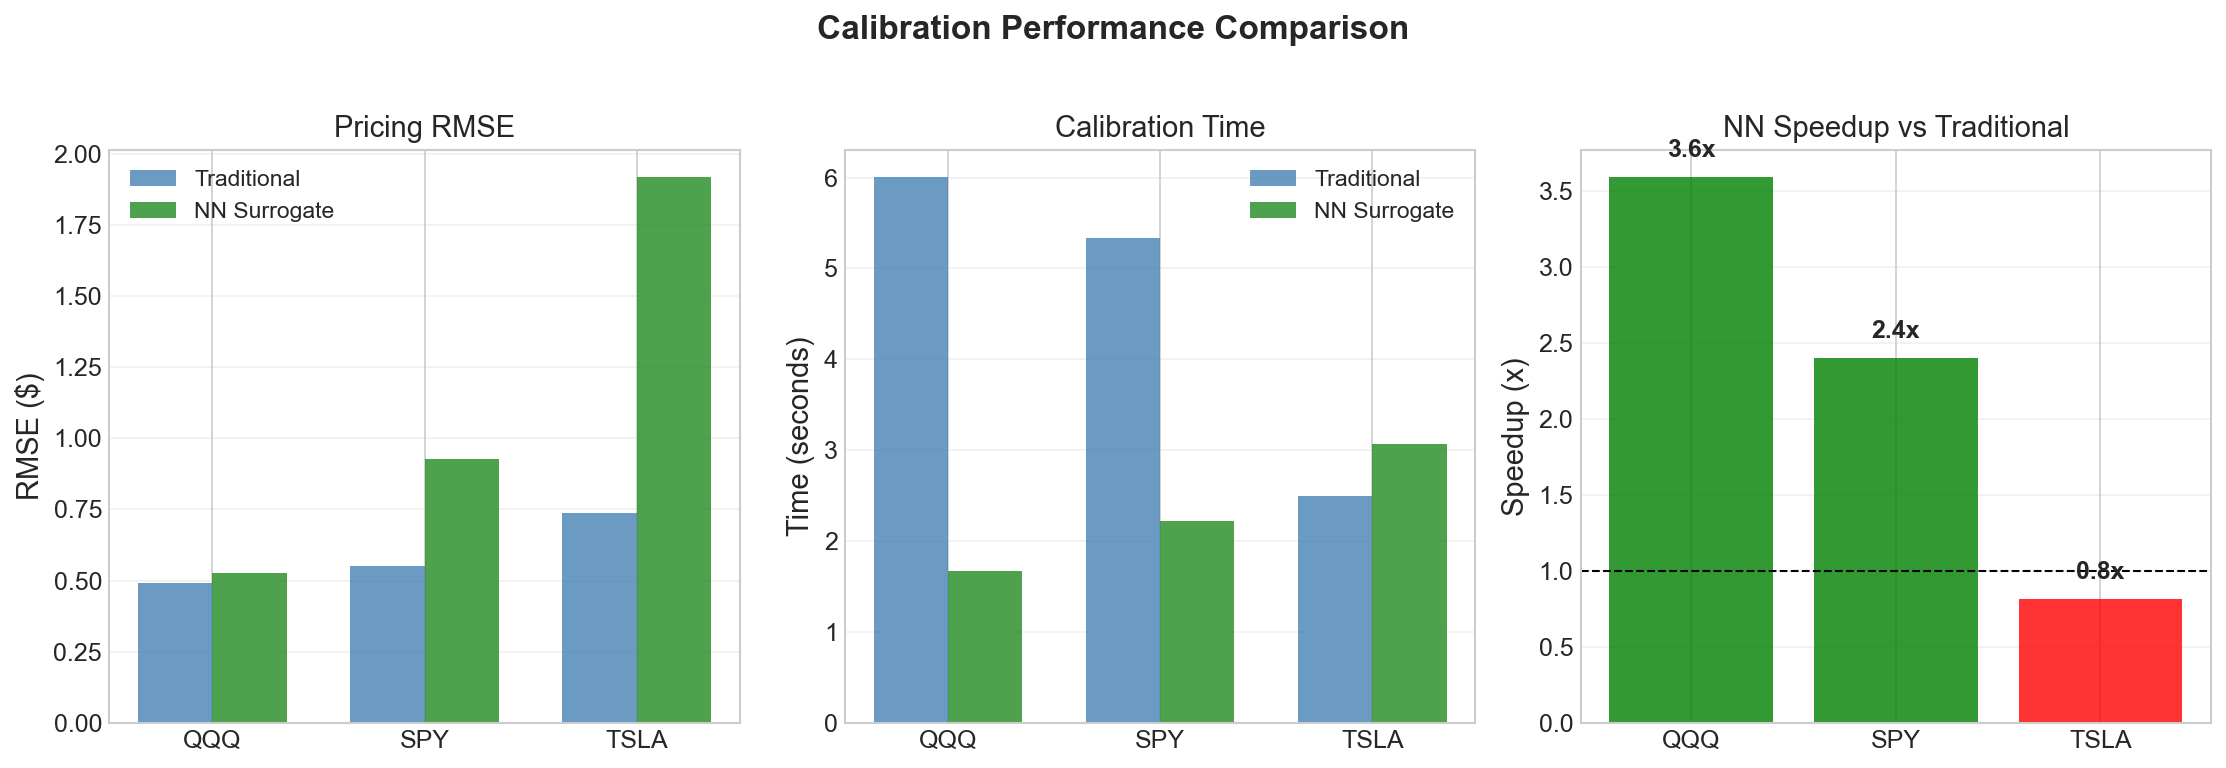

In [6]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x = np.arange(len(tickers))
width = 0.35

# RMSE
ax = axes[0]
trad_rmse = [results[t]['traditional']['rmse'] for t in tickers]
nn_rmse = [results[t]['nn_surrogate']['rmse'] for t in tickers]
bars1 = ax.bar(x - width/2, trad_rmse, width, label='Traditional', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, nn_rmse, width, label='NN Surrogate', color='forestgreen', alpha=0.8)
ax.set_ylabel('RMSE ($)')
ax.set_title('Pricing RMSE')
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Time
ax = axes[1]
trad_time = [results[t]['traditional']['time'] for t in tickers]
nn_time = [results[t]['nn_surrogate']['time'] for t in tickers]
ax.bar(x - width/2, trad_time, width, label='Traditional', color='steelblue', alpha=0.8)
ax.bar(x + width/2, nn_time, width, label='NN Surrogate', color='forestgreen', alpha=0.8)
ax.set_ylabel('Time (seconds)')
ax.set_title('Calibration Time')
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Speedup
ax = axes[2]
speedups = [results[t]['speedup'] for t in tickers]
colors = ['green' if s > 1 else 'red' for s in speedups]
bars = ax.bar(x, speedups, color=colors, alpha=0.8)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Break-even')
ax.set_ylabel('Speedup (x)')
ax.set_title('NN Speedup vs Traditional')
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.grid(axis='y', alpha=0.3)

for bar, s in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
           f'{s:.1f}x', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Calibration Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'performance_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'performance_comparison.pdf', bbox_inches='tight')
plt.show()

---

## 3. Calibrated Parameters

In [7]:
# Parameter comparison table
param_data = []

for ticker in tickers:
    r = results[ticker]
    trad_p = r['traditional']['params']
    nn_p = r['nn_surrogate']['params']
    
    for param in ['v0', 'kappa', 'theta', 'sigma', 'rho']:
        param_data.append({
            'Ticker': ticker,
            'Parameter': param,
            'Traditional': trad_p[param],
            'NN Surrogate': nn_p[param],
            'Difference': nn_p[param] - trad_p[param],
            'Rel Diff (%)': (nn_p[param] - trad_p[param]) / abs(trad_p[param]) * 100 if trad_p[param] != 0 else 0
        })

params_df = pd.DataFrame(param_data)
print("\nCALIBRATED PARAMETERS")
print(params_df.to_string(index=False))


CALIBRATED PARAMETERS
Ticker Parameter  Traditional  NN Surrogate  Difference  Rel Diff (%)
   QQQ        v0     0.028281      0.027685   -0.000596     -2.107077
   QQQ     kappa     4.000000      3.542623   -0.457377    -11.434430
   QQQ     theta     0.051250      0.052200    0.000950      1.852986
   QQQ     sigma     0.400000      0.379381   -0.020619     -5.154683
   QQQ       rho    -0.807437     -0.804565    0.002872      0.355664
   SPY        v0     0.013160      0.010521   -0.002639    -20.053137
   SPY     kappa     4.000000      3.736749   -0.263251     -6.581284
   SPY     theta     0.029578      0.030062    0.000484      1.637269
   SPY     sigma     0.294051      0.334034    0.039982     13.597042
   SPY       rho    -0.874502     -0.859604    0.014897      1.703541
  TSLA        v0     0.193877      0.195724    0.001847      0.952511
  TSLA     kappa     4.000000      1.291567   -2.708433    -67.710834
  TSLA     theta     0.367850      0.451828    0.083979     22.8295

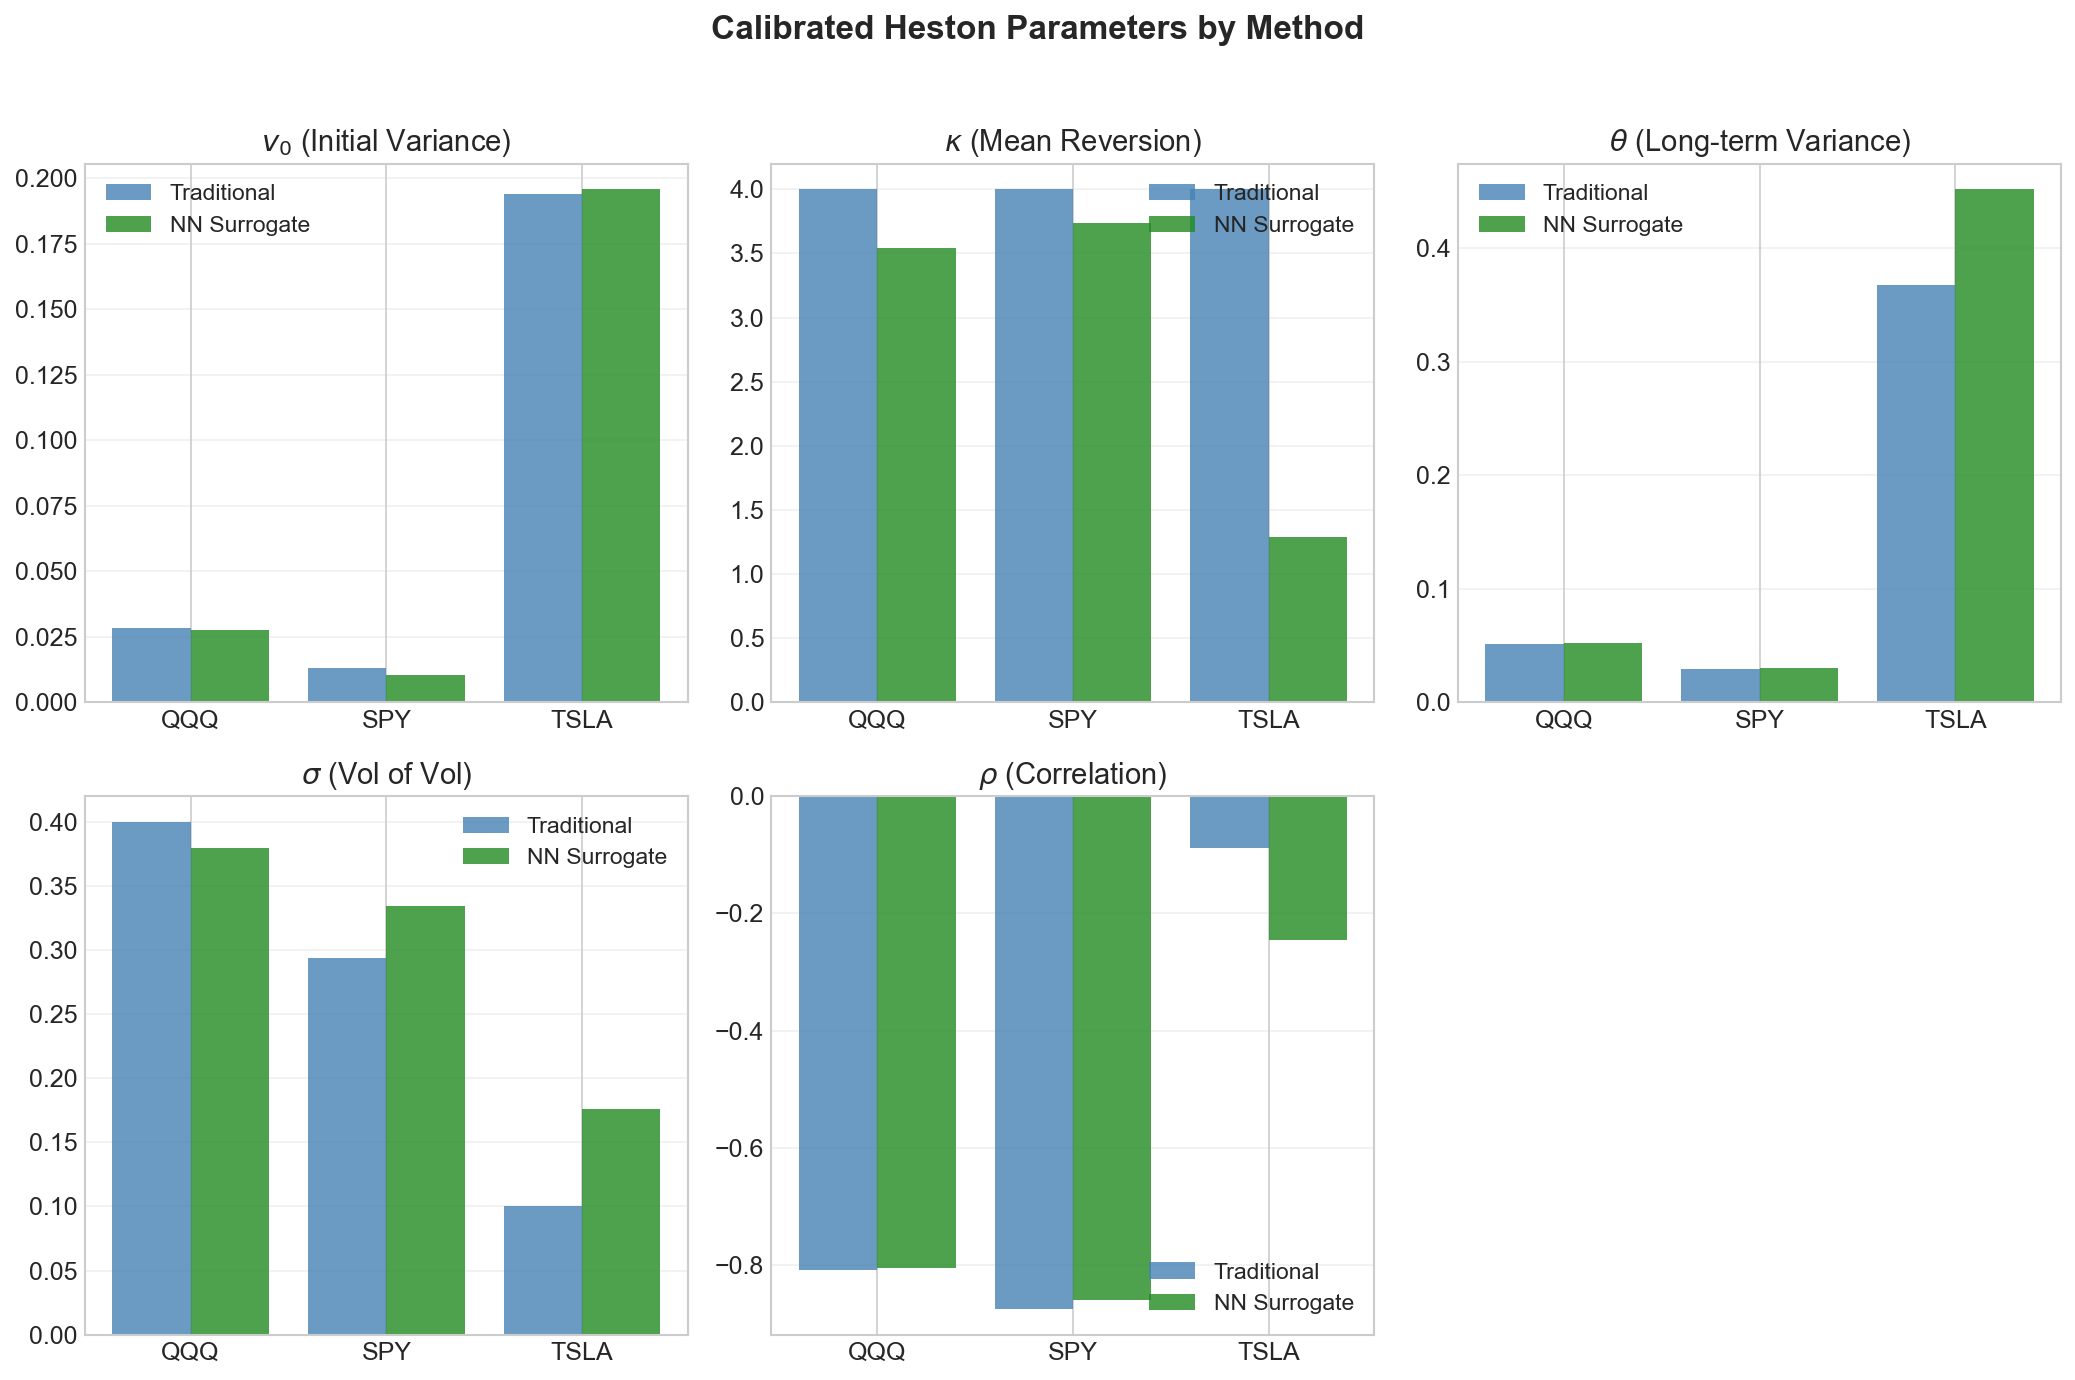

In [8]:
# Visual parameter comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
params = ['v0', 'kappa', 'theta', 'sigma', 'rho']
param_labels = {
    'v0': r'$v_0$ (Initial Variance)',
    'kappa': r'$\kappa$ (Mean Reversion)',
    'theta': r'$\theta$ (Long-term Variance)',
    'sigma': r'$\sigma$ (Vol of Vol)',
    'rho': r'$\rho$ (Correlation)'
}

for ax, param in zip(axes.flat[:5], params):
    trad_vals = [results[t]['traditional']['params'][param] for t in tickers]
    nn_vals = [results[t]['nn_surrogate']['params'][param] for t in tickers]
    
    x = np.arange(len(tickers))
    ax.bar(x - 0.2, trad_vals, 0.4, label='Traditional', color='steelblue', alpha=0.8)
    ax.bar(x + 0.2, nn_vals, 0.4, label='NN Surrogate', color='forestgreen', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(tickers)
    ax.set_title(param_labels[param])
    ax.legend(loc='best')
    ax.grid(axis='y', alpha=0.3)

# Hide last subplot
axes.flat[-1].axis('off')

plt.suptitle('Calibrated Heston Parameters by Method', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'parameter_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'parameter_comparison.pdf', bbox_inches='tight')
plt.show()

---

## 4. Pricing Accuracy Analysis

In [9]:
def compute_model_prices(params, calib_df):
    """Compute Heston prices for calibration options."""
    S = calib_df['spot'].iloc[0]
    r = calib_df['r'].iloc[0] if 'r' in calib_df.columns else 0.04
    
    model = HestonModel(
        v0=params['v0'], kappa=params['kappa'], theta=params['theta'],
        sigma=params['sigma'], rho=params['rho'], r=r
    )
    
    prices = []
    for _, row in calib_df.iterrows():
        price = model.call_price_fft(S, row['strike'], row['tau'])
        prices.append(price)
    
    return np.array(prices)

In [10]:
# Compute prices and errors for each ticker
pricing_analysis = {}

for ticker in tickers:
    if ticker not in calibration_data:
        continue
    
    calib_df = calibration_data[ticker]
    market_prices = calib_df['mid_price'].values
    
    # Traditional prices
    trad_params = results[ticker]['traditional']['params']
    trad_prices = compute_model_prices(trad_params, calib_df)
    trad_errors = trad_prices - market_prices
    
    # NN prices
    nn_params = results[ticker]['nn_surrogate']['params']
    nn_prices = compute_model_prices(nn_params, calib_df)
    nn_errors = nn_prices - market_prices
    
    pricing_analysis[ticker] = {
        'market': market_prices,
        'trad': trad_prices,
        'nn': nn_prices,
        'trad_errors': trad_errors,
        'nn_errors': nn_errors,
        'moneyness': calib_df['moneyness'].values,
        'tau': calib_df['tau'].values
    }

print("Pricing analysis computed for:", list(pricing_analysis.keys()))

Pricing analysis computed for: ['QQQ', 'SPY', 'TSLA']


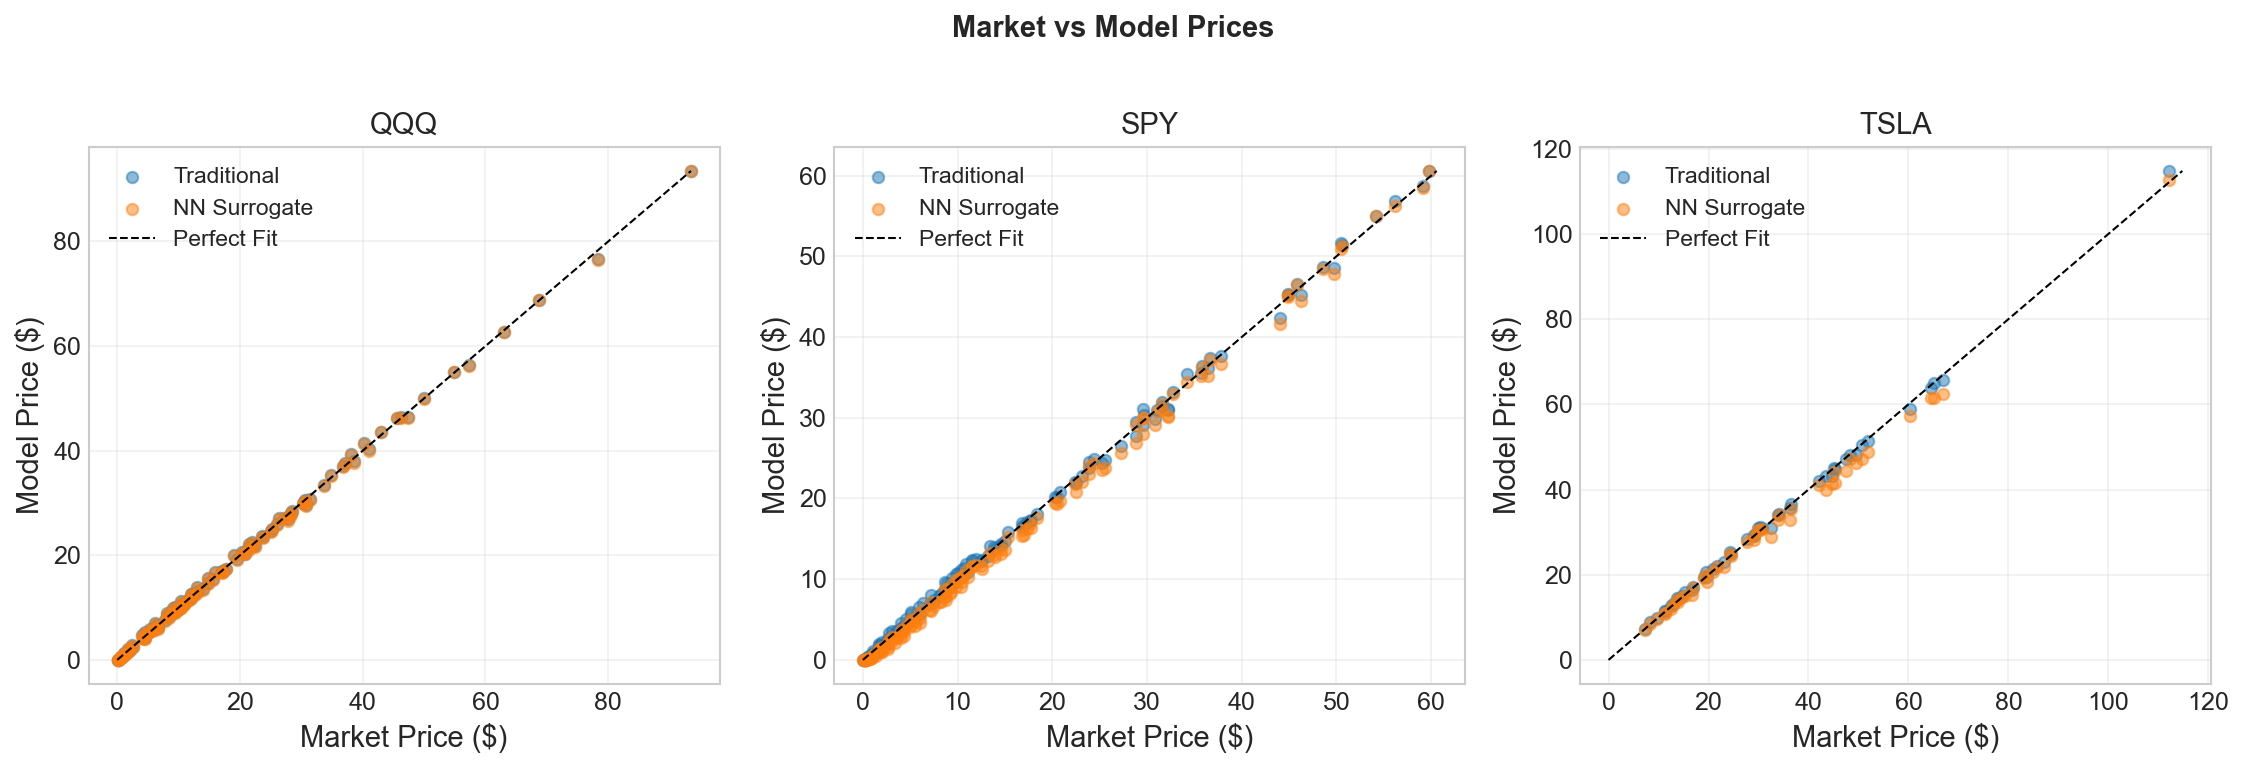

In [11]:
# Market vs Model prices scatter plot
fig, axes = plt.subplots(1, len(tickers), figsize=(5*len(tickers), 5))

if len(tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, tickers):
    if ticker not in pricing_analysis:
        continue
    
    pa = pricing_analysis[ticker]
    
    ax.scatter(pa['market'], pa['trad'], alpha=0.5, label='Traditional', s=30)
    ax.scatter(pa['market'], pa['nn'], alpha=0.5, label='NN Surrogate', s=30)
    
    # Perfect fit line
    max_price = max(pa['market'].max(), pa['trad'].max(), pa['nn'].max())
    ax.plot([0, max_price], [0, max_price], 'k--', linewidth=1, label='Perfect Fit')
    
    ax.set_xlabel('Market Price ($)')
    ax.set_ylabel('Model Price ($)')
    ax.set_title(f'{ticker}')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Market vs Model Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'market_vs_model_prices.png', dpi=300, bbox_inches='tight')
plt.show()

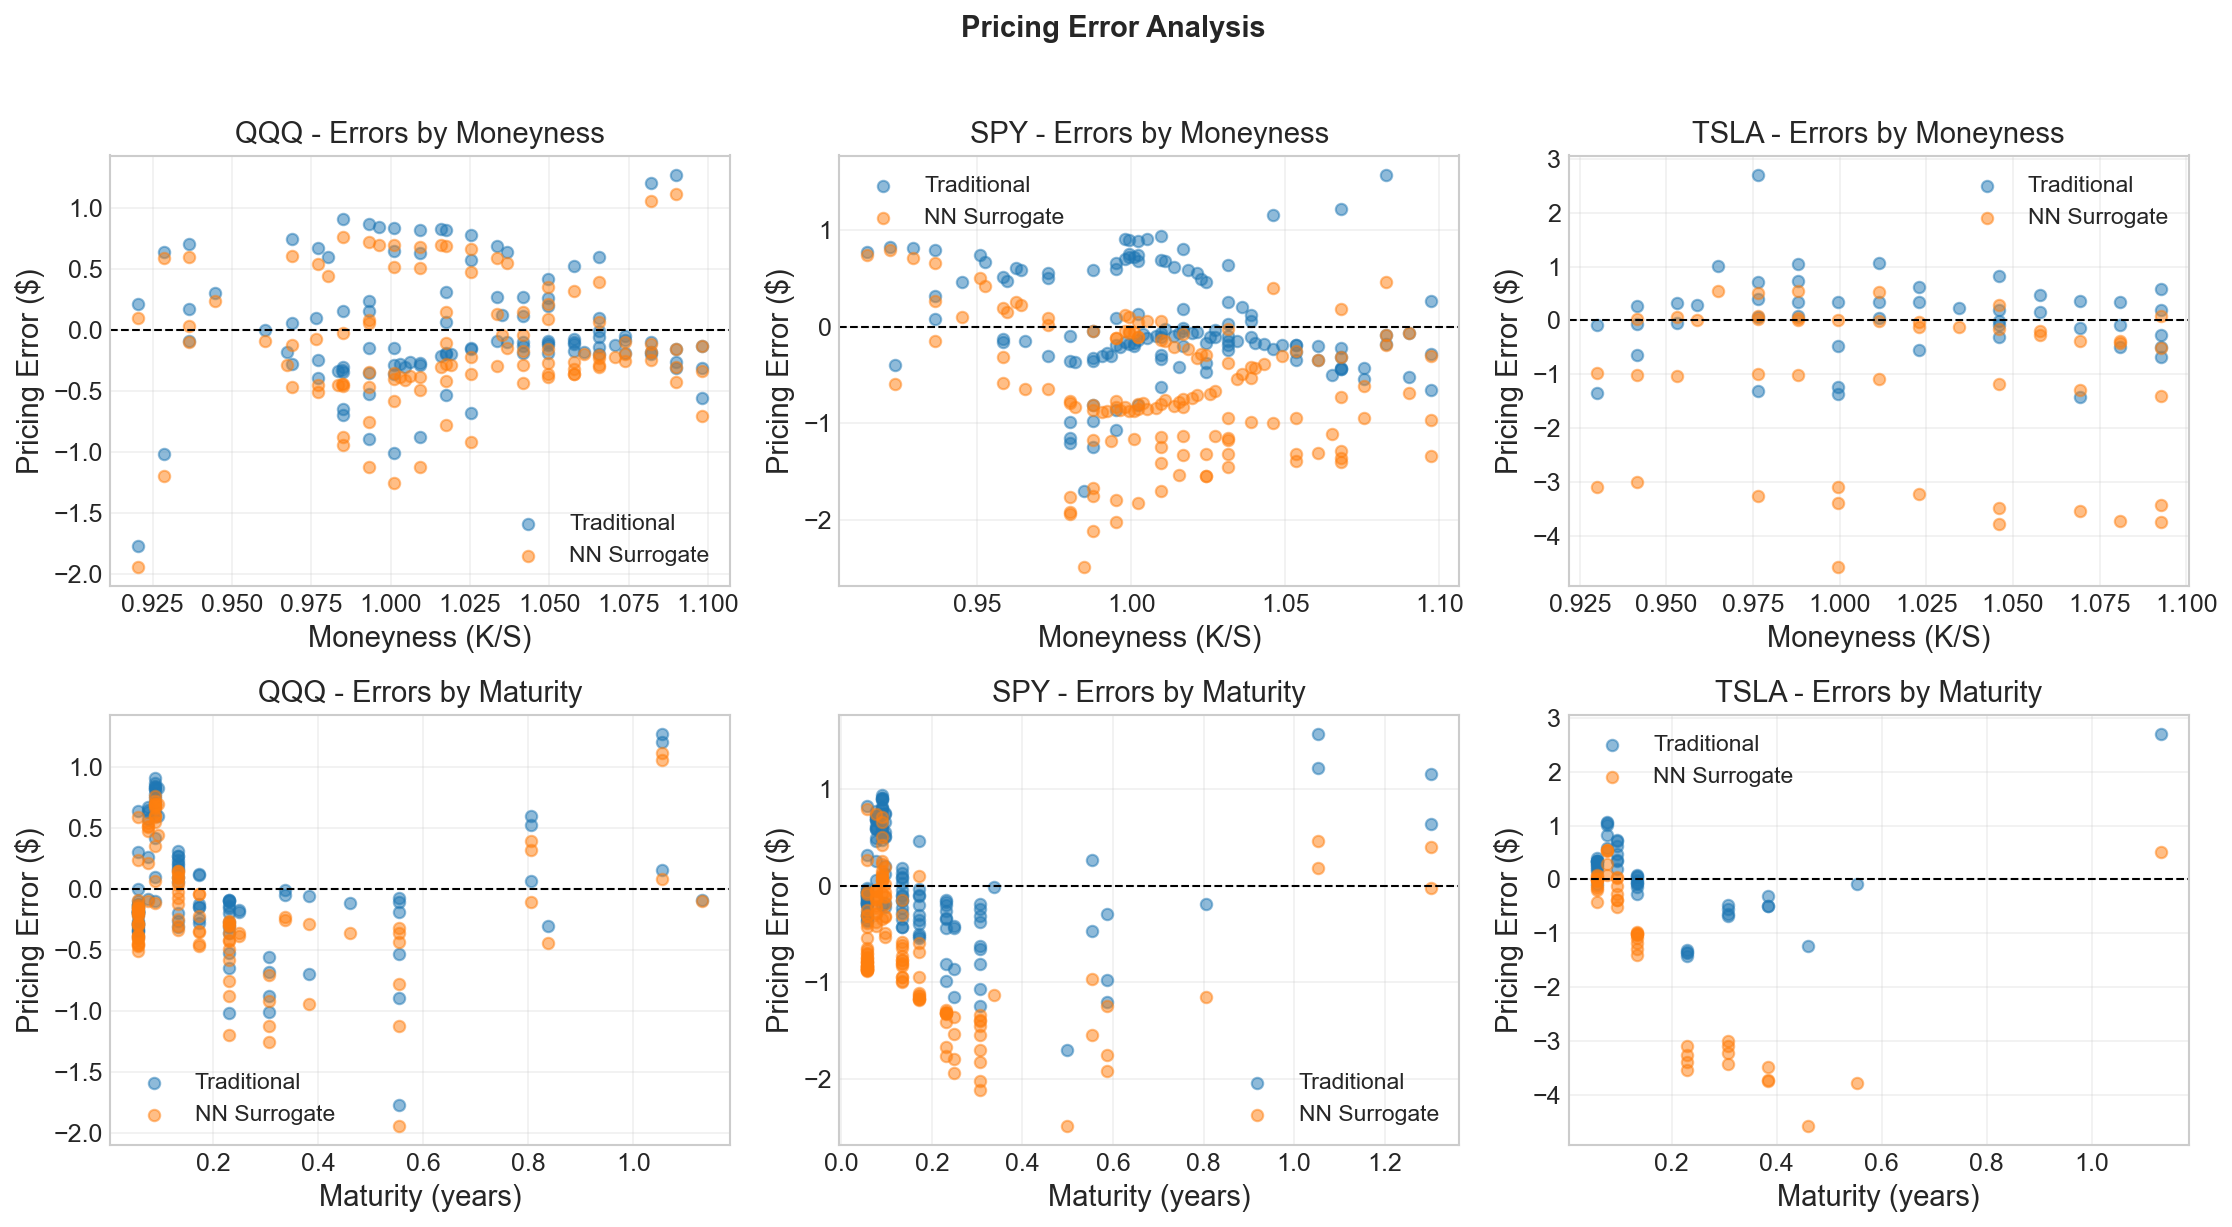

In [12]:
# Error analysis by moneyness and maturity
fig, axes = plt.subplots(2, len(tickers), figsize=(5*len(tickers), 8))

if len(tickers) == 1:
    axes = axes.reshape(-1, 1)

for col, ticker in enumerate(tickers):
    if ticker not in pricing_analysis:
        continue
    
    pa = pricing_analysis[ticker]
    
    # Errors by moneyness
    ax = axes[0, col]
    ax.scatter(pa['moneyness'], pa['trad_errors'], alpha=0.5, label='Traditional', s=30)
    ax.scatter(pa['moneyness'], pa['nn_errors'], alpha=0.5, label='NN Surrogate', s=30)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Moneyness (K/S)')
    ax.set_ylabel('Pricing Error ($)')
    ax.set_title(f'{ticker} - Errors by Moneyness')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Errors by maturity
    ax = axes[1, col]
    ax.scatter(pa['tau'], pa['trad_errors'], alpha=0.5, label='Traditional', s=30)
    ax.scatter(pa['tau'], pa['nn_errors'], alpha=0.5, label='NN Surrogate', s=30)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Pricing Error ($)')
    ax.set_title(f'{ticker} - Errors by Maturity')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Pricing Error Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 5. Implied Volatility Surface

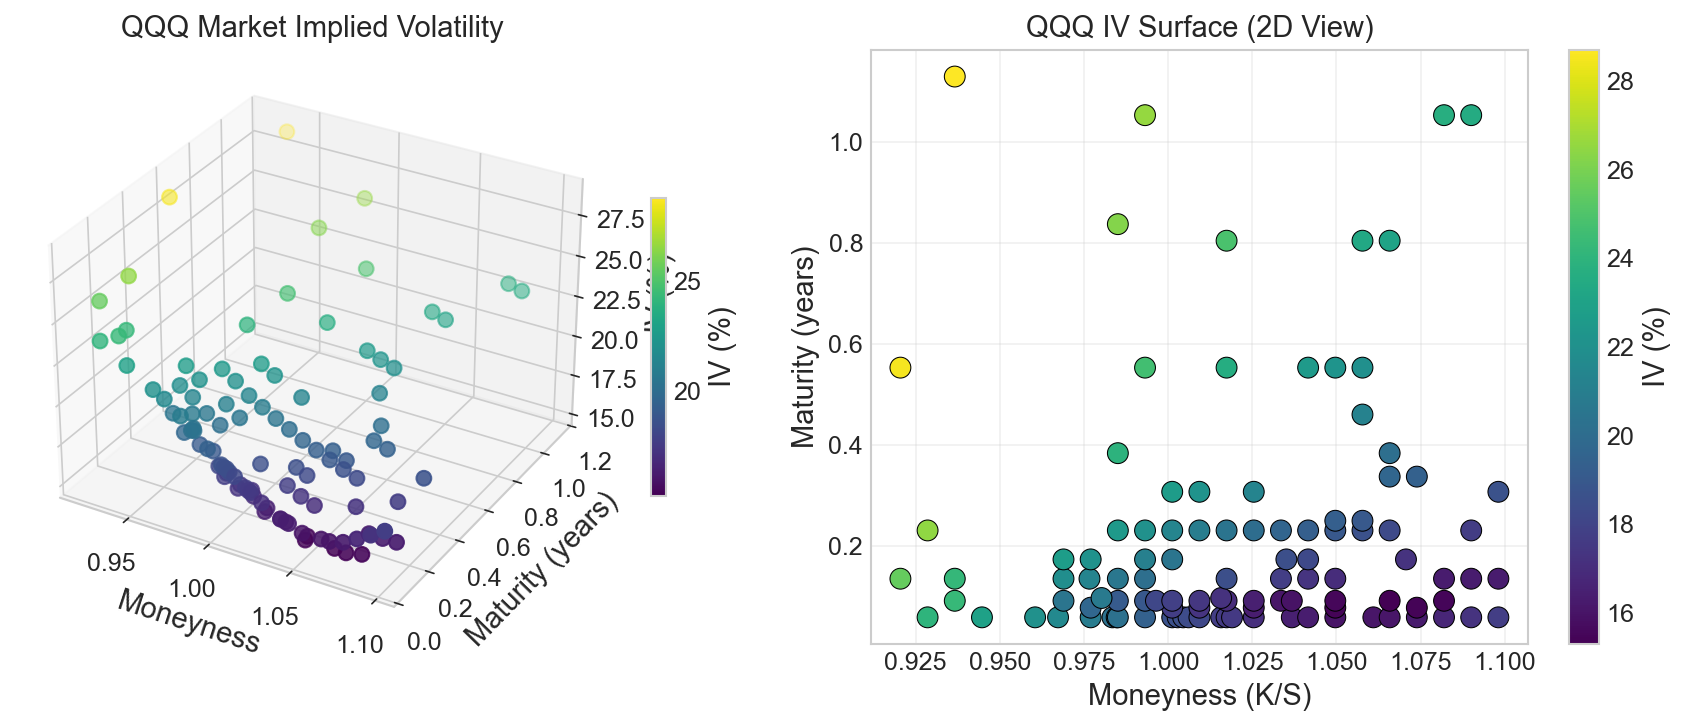

In [13]:
# Plot implied volatility surface for first ticker
ticker = tickers[0]
if ticker in calibration_data:
    calib_df = calibration_data[ticker]
    
    fig = plt.figure(figsize=(12, 5))
    
    # Market IV surface
    ax1 = fig.add_subplot(121, projection='3d')
    sc1 = ax1.scatter(calib_df['moneyness'], calib_df['tau'], 
                     calib_df['impliedVolatility']*100,
                     c=calib_df['impliedVolatility']*100, cmap='viridis', s=50)
    ax1.set_xlabel('Moneyness')
    ax1.set_ylabel('Maturity (years)')
    ax1.set_zlabel('IV (%)')
    ax1.set_title(f'{ticker} Market Implied Volatility')
    plt.colorbar(sc1, ax=ax1, shrink=0.5, label='IV (%)')
    
    # 2D heatmap view
    ax2 = fig.add_subplot(122)
    scatter = ax2.scatter(calib_df['moneyness'], calib_df['tau'],
                         c=calib_df['impliedVolatility']*100, 
                         cmap='viridis', s=100, edgecolors='black', linewidth=0.5)
    ax2.set_xlabel('Moneyness (K/S)')
    ax2.set_ylabel('Maturity (years)')
    ax2.set_title(f'{ticker} IV Surface (2D View)')
    plt.colorbar(scatter, ax=ax2, label='IV (%)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{ticker}_iv_surface.png', dpi=300, bbox_inches='tight')
    plt.show()

---

## 6. Underlying Statistics

In [14]:
# Underlying statistics table
stats_data = []

for ticker in tickers:
    if 'underlying_stats' in results[ticker]:
        stats = results[ticker]['underlying_stats']
        stats_data.append({
            'Ticker': ticker,
            'Current Vol (%)': stats['current_vol'] * 100,
            'Mean Vol (%)': stats['mean_vol'] * 100,
            'Vol of Vol': stats['vol_of_vol'],
            'Leverage Corr': stats['leverage_corr'],
            'κ Estimate': stats['kappa_estimate'],
            'Skewness': stats['skewness'],
            'Kurtosis': stats['kurtosis']
        })

stats_df = pd.DataFrame(stats_data)
print("\nUNDERLYING STATISTICS (from historical data)")
print(stats_df.to_string(index=False))

stats_df.to_csv(TABLES_DIR / 'underlying_statistics.csv', index=False)
stats_df.to_latex(TABLES_DIR / 'underlying_statistics.tex', index=False,
                  float_format='%.4f', caption='Underlying Securities Statistics',
                  label='tab:statistics')


UNDERLYING STATISTICS (from historical data)
Ticker  Current Vol (%)  Mean Vol (%)  Vol of Vol  Leverage Corr  κ Estimate  Skewness  Kurtosis
   QQQ        21.060223     17.010402    0.045786      -0.507437         2.0 -0.903107  1.918966
   SPY        14.774060     12.268220    0.029674      -0.574502         2.0 -1.031166  2.218659
  TSLA        53.132451     50.193622    0.023867      -0.387839         2.0 -0.168687 -0.428443


---

## 7. Export Summary for Dissertation

In [15]:
# Create comprehensive summary
summary = {
    'title': 'Heston Model Deep Learning Calibration Results',
    'date': master_results['timestamp'],
    'tickers': tickers,
    'method_comparison': {
        'traditional': {
            'avg_rmse': np.mean([results[t]['traditional']['rmse'] for t in tickers]),
            'avg_mae': np.mean([results[t]['traditional']['mae'] for t in tickers]),
            'avg_time': np.mean([results[t]['traditional']['time'] for t in tickers])
        },
        'nn_surrogate': {
            'avg_rmse': np.mean([results[t]['nn_surrogate']['rmse'] for t in tickers]),
            'avg_mae': np.mean([results[t]['nn_surrogate']['mae'] for t in tickers]),
            'avg_time': np.mean([results[t]['nn_surrogate']['time'] for t in tickers])
        },
        'avg_speedup': np.mean([results[t]['speedup'] for t in tickers])
    },
    'figures_saved': [
        'performance_comparison.png',
        'parameter_comparison.png',
        'market_vs_model_prices.png',
        'error_analysis.png'
    ],
    'tables_saved': [
        'performance_comparison.csv',
        'underlying_statistics.csv'
    ]
}

print("\n" + "="*70)
print("DISSERTATION SUMMARY")
print("="*70)
print(f"\nMethod Comparison (averaged across {len(tickers)} securities):")
print(f"\n{'Metric':<20} {'Traditional':>15} {'NN Surrogate':>15}")
print("-" * 52)
print(f"{'RMSE ($)':<20} {summary['method_comparison']['traditional']['avg_rmse']:>15.4f} "
      f"{summary['method_comparison']['nn_surrogate']['avg_rmse']:>15.4f}")
print(f"{'MAE ($)':<20} {summary['method_comparison']['traditional']['avg_mae']:>15.4f} "
      f"{summary['method_comparison']['nn_surrogate']['avg_mae']:>15.4f}")
print(f"{'Time (s)':<20} {summary['method_comparison']['traditional']['avg_time']:>15.2f} "
      f"{summary['method_comparison']['nn_surrogate']['avg_time']:>15.2f}")
print(f"\nAverage Speedup: {summary['method_comparison']['avg_speedup']:.1f}x")

# Save summary
with open(TABLES_DIR / 'dissertation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nFigures saved to: {FIGURES_DIR}")
print(f"Tables saved to: {TABLES_DIR}")


DISSERTATION SUMMARY

Method Comparison (averaged across 3 securities):

Metric                   Traditional    NN Surrogate
----------------------------------------------------
RMSE ($)                      0.5941          1.1246
MAE ($)                       0.4484          0.8205
Time (s)                        4.61            2.32

Average Speedup: 2.3x

Figures saved to: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/results/figures
Tables saved to: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/results/tables


In [16]:
# List all saved files
print("\nSAVED FILES:")
print("\nFigures:")
for f in sorted(FIGURES_DIR.glob('*')):
    print(f"  - {f.name}")

print("\nTables:")
for f in sorted(TABLES_DIR.glob('*')):
    print(f"  - {f.name}")


SAVED FILES:

Figures:
  - QQQ_iv_surface.png
  - error_analysis.png
  - market_vs_model_prices.png
  - parameter_comparison.pdf
  - parameter_comparison.png
  - performance_comparison.pdf
  - performance_comparison.png

Tables:
  - dissertation_summary.json
  - performance_comparison.csv
  - performance_comparison.tex
  - underlying_statistics.csv
  - underlying_statistics.tex
